<a href="https://colab.research.google.com/github/divyasuresh1450-ai/Python-For-Data-Science-/blob/main/practical08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical no: 8

Name: Divya Suresh Gaikwad ,
Class: SY-A,
Roll no:64


> Add blockquote



Aim:To implement and analyze the relationship between variables using Karl Pearson’s correlation coefficient and simple linear regression, and to interpret the results using a given dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving aistudent.csv to aistudent.csv


In [ ]:
import pandas as pd
df=pd.read_csv('aistudent.csv')
df.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


In [ ]:
import numpy as np

x = df['Daily_Usage_Hours']
y = df['Age']

r = np.corrcoef(x, y)[0, 1]

print("Karl Pearson Correlation Coefficient:", r)

Karl Pearson Correlation Coefficient: 0.0008232137518531507


In [ ]:
correlation = df['Daily_Usage_Hours'].corr(df['Age'])

print("Correlation (Pandas Method):", correlation)

Correlation (Pandas Method): 0.0008232137518531507


In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['Daily_Usage_Hours']]   # Independent variable
Y = df['Age']                  # Dependent variable

model = LinearRegression()
model.fit(X, Y)

print("Slope (b1):", model.coef_[0])
print("Intercept (b0):", model.intercept_)

Slope (b1): 0.0015491242800444401
Intercept (b0): 19.42045525664342


In [ ]:
# Predict Age when usage = 5 hours
predicted = model.predict([[5]])

print("Predicted Age:", predicted[0])

Predicted Age: 19.428200878043643


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


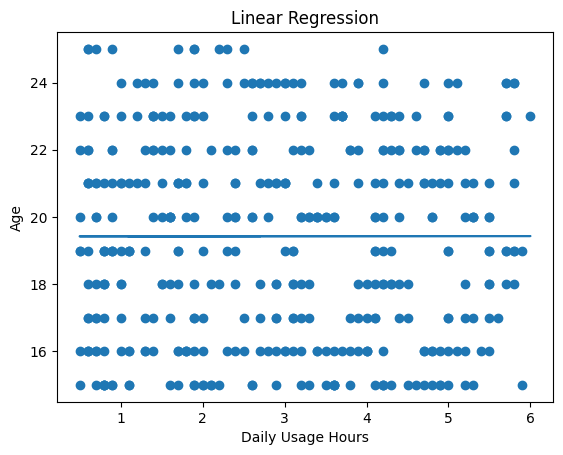

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)

plt.scatter(df['Daily_Usage_Hours'], df['Age'])
plt.plot(df['Daily_Usage_Hours'], y_pred)

plt.xlabel("Daily Usage Hours")
plt.ylabel("Age")
plt.title("Linear Regression")

plt.show()

In [ ]:
# Mean values
x_mean = np.mean(x)
y_mean = np.mean(y)

# Slope (b1)
num = np.sum((x - x_mean) * (y - y_mean))
den = np.sum((x - x_mean)**2)

b1 = num / den

# Intercept (b0)
b0 = y_mean - b1 * x_mean

print("Manual Slope (b1):", b1)
print("Manual Intercept (b0):", b0)

Manual Slope (b1): 0.001549124280044505
Manual Intercept (b0): 19.42045525664342


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 8.92936894873328


1. What is correlation? How is it different from regression?

Correlation measures the strength and direction of relationship between two variables.
 It's Value ranges from -1 to +1
Example: Study hours and marks

| Feature   | Correlation           | Regression            |
| --------- | --------------------- | --------------------- |
| Purpose   | Measures relationship | Predicts relationship |
| Output    | Single value (r)      | Equation (line)       |
| Direction | No cause-effect       | Shows dependency      |
| Example   | r = 0.8               | Y = 2X + 5            |


2.What is simple linear regression? Explain with suitable example?

Simple Linear Regression is a method used to predict one variable using another variable.
It follows the equation:
Y=b0+b1X

	​


X → Independent variable
Y → Dependent variable
b
0
	​

 → Intercept
b
1
	​

 → Slope
 Example:
X = Study Hours
Y = Marks

If:

Y=5X+10

 For 4 hours:

Y=5(4)+10=30

So, predicted marks = 30

3. How do you calculate Pearson correlation in Python?

Using NumPy:

In [ ]:
import numpy as np

r = np.corrcoef(x, y)[0, 1]
print(r)

0.0008232137518531507


Using Pandas:


In [ ]:
r = df['Daily_Usage_Hours'].corr(df['Age'])
print(r)

0.0008232137518531507


4. What is multicollinearity? Does it affect simple regression?



Multicollinearity occurs when independent variables are highly correlated with each other.

Example:
Height (cm) and Height (inches)
 Effect:
Makes model unstable
Difficult to interpret coefficients
 In Simple Linear Regression:
 Does NOT affect much
 Because there is only ONE independent variable


 5. A dataset shows strong correlation but poor prediction accuracy. Why?

This situation can happen due to several reasons:

 Possible Causes:
Non-linear relationship
Correlation measures linear relation only
Data may be curved
Outliers
Extreme values disturb regression line
Overfitting / Underfitting
Model not properly trained
Low R² score
Correlation may be high but prediction weak
Missing important variables
One variable alone is not enough